In [3]:
print("hello langgraph!")

hello langgraph!


In [ ]:
# LLM CODE
from dotenv import load_dotenv
load_dotenv()
import os
api_key = os.getenv("GROQ_API_KEY")
from langchain_groq import ChatGroq
llm = ChatGroq(model="openai/gpt-oss-20b")
res=llm.invoke("Hello, how are you?")
print(res)
print(res.content)


content='Hello! I’m doing great—thanks for asking. How can I help you today?' additional_kwargs={'reasoning_content': "We need to respond politely. There's no special instructions."} response_metadata={'token_usage': {'completion_tokens': 39, 'prompt_tokens': 77, 'total_tokens': 116, 'completion_time': 0.039903497, 'completion_tokens_details': {'reasoning_tokens': 12}, 'prompt_time': 0.003673342, 'prompt_tokens_details': None, 'queue_time': 0.352639664, 'total_time': 0.043576839}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_84bb35977d', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--01a0fc76-244d-7a02-87f1-105eb26bcb39-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 77, 'output_tokens': 39, 'total_tokens': 116, 'output_token_details': {'reasoning': 12}}
Hello! I’m doing great—thanks for asking. How can I help you today?


Building the Graph Using Langgraph

In [21]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel 

class State(BaseModel):
    messages: str= ""

def greet(state: State):
    print(state.messages)
    return {"messages": state.messages + "Hello! How can I help you today?"}

graph=StateGraph(State)

graph.add_node("welcome",greet)

graph.add_edge(START,"welcome")
graph.add_edge("welcome",END)

final_graph=graph.compile()

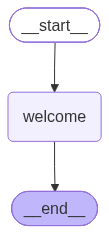

In [22]:
final_graph

In [23]:
final_graph.invoke({"messages": ""})

{'messages': 'Hello! How can I help you today?'}

In [24]:
final_graph.invoke({"messages": "HI "})

HI 


{'messages': 'HI Hello! How can I help you today?'}

Multi Node Graph

In [30]:
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel

class State(BaseModel):
    text: str = ""
    score: int= 0
    comment: str= ""

In [32]:
from random import randint
def score(state:State):
    state.score=randint(1,10)
    return {
        "score":state.score
    }

def comment(state:State):
    if state.score>5:
        state.comment="Great job!"
    else:
        state.comment="Keep up the good work!"
    return {
        "comment":state.comment
    }

graph=StateGraph(State)
graph.add_node("score",score)
graph.add_node("comment",comment)

graph.add_edge(START,"score")
graph.add_edge("score","comment")   
graph.add_edge("comment",END)

final_graph=graph.compile()



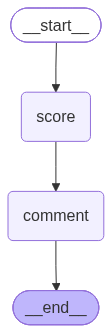

In [33]:
final_graph

In [38]:
final_graph.invoke({"text":"This is a test."})

{'text': 'This is a test.', 'score': 5, 'comment': 'Keep up the good work!'}